# Phase 4 - Streaming Pipeline

Student: Mike Sayanka Lekaram

ID: GC3183502

Module: Thesis / Dissertation

Institution: Griffith College Dublin

## What this notebook does

In Phase 3 I trained the BERT+BiLSTM model and saved it to Drive.
In this phase I plug that model into a real-time streaming pipeline.

The pipeline works like this:

  WELFake CSV
      |
      v
  Kafka producer  (sends articles one by one to a Kafka topic)
      |
      v
  Kafka topic     (acts as a message queue)
      |
      v
  Spark Streaming (reads from Kafka in micro-batches)
      |
      v
  BERT+BiLSTM     (classifies each article as real or fake)
      |
      v
  Cassandra       (stores the results permanently)

Because Colab is a single machine you can run Kafka, Spark
and Cassandra all locally. This simulates the distributed
architecture described in my thesis methodology chapter in my case i run everything from colab.

NOTE: connect T4 GPU first.
Runtime -> Change runtime type -> T4 GPU -> Save

## 1.  Mount Drive and install everything needed

This installs Java (needed for Kafka and Spark), Kafka,
Spark, Cassandra driver, and the transformer library.
Takes about 3-4 minutes.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

base      = '/content/drive/MyDrive/FakeNewsThesis'
data_dir  = base + '/data'
model_dir = base + '/model'

print('Drive mounted')

# install java - both Kafka and Spark need it
print('installing Java...')
os.system('apt-get install -y default-jdk -q')

# set java home so Spark can find it
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

# install python packages
print('installing python packages...')
os.system('pip install kafka-python pyspark cassandra-driver transformers==4.41.0 -q')

# download Kafka binaries
print('downloading Kafka...')
os.system('wget -q https://downloads.apache.org/kafka/3.7.0/kafka_2.13-3.7.0.tgz')
os.system('tar -xzf kafka_2.13-3.7.0.tgz')
os.system('mv kafka_2.13-3.7.0 /content/kafka')

# install Cassandra
print('installing Cassandra...')
os.system('pip install cassandra-driver -q')

print('all done')

Mounted at /content/drive
Drive mounted
installing Java...
installing python packages...
downloading Kafka...
installing Cassandra...
all done


## 2. Start Kafka

Kafka needs a broker running before anything can send or
receive messages. I am using KRaft mode which does not
need ZooKeeper - simpler to set up.

In [8]:
import os, time, subprocess

kafka_dir = '/content/kafka'

# set java home so kafka can find it
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

# check if kafka downloaded correctly in step 1
# if not download it again here
if not os.path.exists(kafka_dir + '/bin/kafka-storage.sh'):
    print('kafka not found - downloading...')
    os.system('rm -rf /content/kafka*')
    os.system(
        'wget -q '
        'https://archive.apache.org/dist/kafka/3.6.1/kafka_2.13-3.6.1.tgz '
        '-O /content/kafka.tgz'
    )
    os.system('tar -xzf /content/kafka.tgz -C /content/')
    os.system('mv /content/kafka_2.13-3.6.1 ' + kafka_dir)
    os.system('rm -f /content/kafka.tgz')
    print('kafka downloaded and extracted')

# make all scripts executable
os.system('chmod +x ' + kafka_dir + '/bin/*.sh')
print('kafka found at:', kafka_dir)

# generate a cluster id for KRaft mode
cluster_id = subprocess.check_output(
    [kafka_dir + '/bin/kafka-storage.sh', 'random-uuid'],
    env={**os.environ}
).decode().strip()
print('cluster id:', cluster_id)

# format the storage directory
os.system(
    '{}/bin/kafka-storage.sh format -t {} -c {}/config/kraft/server.properties'.format(
        kafka_dir, cluster_id, kafka_dir)
)

# start the broker in the background
kafka_process = subprocess.Popen(
    [kafka_dir + '/bin/kafka-server-start.sh',
     kafka_dir + '/config/kraft/server.properties'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    env={**os.environ}
)

print('waiting for Kafka to start...')
time.sleep(10)

# create the news-articles topic
result = os.popen(
    '{}/bin/kafka-topics.sh --create --topic news-articles '
    '--bootstrap-server localhost:9092 '
    '--partitions 1 --replication-factor 1 2>&1'.format(kafka_dir)
).read()
print(result)

# confirm topic was created
topics = os.popen(
    '{}/bin/kafka-topics.sh --list '
    '--bootstrap-server localhost:9092 2>&1'.format(kafka_dir)
).read()
print('topics available:', topics.strip())
print('Kafka is running on localhost:9092')

kafka not found - downloading...
kafka downloaded and extracted
kafka found at: /content/kafka
cluster id: eMZ99Sy4TuKGAQPeh2D7zA
waiting for Kafka to start...
Created topic news-articles.

topics available: news-articles
Kafka is running on localhost:9092


## 3. Import libraries and load the trained model

This loads the BERT+BiLSTM model I saved in Phase 3.
The model will be used inside the Spark pipeline to
classify each article that comes through.

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import json
import re
import warnings
from transformers import BertTokenizer, AutoModel

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

BERT_MODEL = 'distilbert-base-uncased'
MAX_LEN    = 128

# rebuild the model class - same as Phase 3
class BertBiLSTMModel(nn.Module):
    def __init__(self, bert_name, hidden=128, num_classes=2, dropout=0.3):
        super(BertBiLSTMModel, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        bert_size = self.bert.config.hidden_size
        self.bilstm = nn.LSTM(
            input_size=bert_size, hidden_size=hidden,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.2
        )
        self.attention = nn.Linear(hidden * 2, 1)
        self.drop  = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden * 2, 64)
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, input_ids, attention_mask=None):
        bert_out = self.bert(
            input_ids=input_ids, attention_mask=attention_mask)
        seq = bert_out.last_hidden_state
        lstm_out, _ = self.bilstm(seq)
        weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        out = self.drop(context)
        out = self.relu(self.dense(out))
        out = self.drop(out)
        return self.fc(out)


# load the tokenizer
print('loading tokenizer...')
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

# load the trained model from Phase 3
checkpoint = model_dir + '/model3_bert_bilstm_hybrid.pt'
print('loading model from:', checkpoint)

model = BertBiLSTMModel(BERT_MODEL)
model.load_state_dict(torch.load(checkpoint, map_location=device))
model = model.to(device)
model.eval()

print('model loaded and ready')


def classify_article(text):
    """
    takes a raw article string and returns the predicted label
    and the confidence score.
    0 = fake, 1 = real
    """
    encoded = tokenizer(
        str(text),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    ids  = encoded['input_ids'].to(device)
    mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=1)
        label  = torch.argmax(probs, dim=1).item()
        conf   = probs[0][label].item()

    return label, round(conf, 4)


# quick test to make sure the model works
test_text = 'Scientists confirm that the new vaccine is safe and effective.'
label, conf = classify_article(test_text)
print()
print('quick test:')
print('  text   :', test_text)
print('  label  :', 'fake' if label == 0 else 'real')
print('  conf   :', conf)
print('model is working correctly')

device: cuda
loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

loading model from: /content/drive/MyDrive/FakeNewsThesis/model/model3_bert_bilstm_hybrid.pt


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model loaded and ready

quick test:
  text   : Scientists confirm that the new vaccine is safe and effective.
  label  : real
  conf   : 0.998
model is working correctly


## 4.  Set up Cassandra simulation using sqlite3

Cassandra will store the classification results from the pipeline.
I am using a simple in-process simulation here because installing
a full Cassandra cluster on Colab is resource heavy.
The schema mirrors what would be used in a real deployment.

I create a keyspace called fakenews and a table called predictions
that stores each article with its predicted label and confidence score.

In [11]:
import sqlite3
from datetime import datetime

# I am using SQLite here to simulate Cassandra storage on Colab
# because Cassandra needs a lot of memory to run alongside Spark
# on a single Colab instance. The schema is identical to what
# I would use in a real Cassandra deployment.
#
# in a production setup this would be:
#   CREATE KEYSPACE fakenews WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1};
#   USE fakenews;
#   CREATE TABLE predictions (
#       article_id  UUID PRIMARY KEY,
#       title       TEXT,
#       content     TEXT,
#       label       INT,
#       label_text  TEXT,
#       confidence  FLOAT,
#       processed   TIMESTAMP
#   );

db_path = base + '/predictions.db'
conn    = sqlite3.connect(db_path)
cursor  = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS predictions (
        article_id  INTEGER PRIMARY KEY AUTOINCREMENT,
        title       TEXT,
        content     TEXT,
        label       INTEGER,
        label_text  TEXT,
        confidence  REAL,
        processed   TEXT
    )
''')
conn.commit()

print('predictions table ready at:', db_path)
print('schema matches Cassandra table design in thesis Chapter 4')


def save_prediction(title, content, label, confidence):
    """
    saves a classification result to the database.
    in a real deployment this would write to Cassandra.
    """
    label_text = 'fake' if label == 0 else 'real'
    cursor.execute(
        'INSERT INTO predictions (title, content, label, label_text, confidence, processed) '
        'VALUES (?, ?, ?, ?, ?, ?)',
        (title, content[:200], label, label_text,
         confidence, datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
    )
    conn.commit()


print('save_prediction function ready')

predictions table ready at: /content/drive/MyDrive/FakeNewsThesis/predictions.db
schema matches Cassandra table design in thesis Chapter 4
save_prediction function ready


## 5.  Kafka producer

This reads articles from the test set CSV and sends them
to the Kafka topic one by one, simulating a live news stream.
Each article is sent as a JSON message.

In [9]:
from kafka import KafkaProducer
import json, time

# load a sample of the test set to stream through the pipeline
test_df = pd.read_csv(data_dir + '/test.csv')
test_df = test_df.dropna(subset=['text', 'label']).reset_index(drop=True)

# use 100 articles for the demo - enough to show the pipeline working
# in a real deployment this would be a live news API feed
sample = test_df.head(100).copy()

print('test set loaded:', len(test_df), 'articles')
print('will stream:', len(sample), 'articles through the pipeline')

# connect to Kafka
producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

print('Kafka producer connected')
print('sending articles to topic: news-articles')
print()

# send each article as a JSON message to the Kafka topic
sent_count = 0
for i, row in sample.iterrows():
    message = {
        'article_id'   : int(i),
        'title'        : str(row['text'])[:100],
        'content'      : str(row['text']),
        'true_label'   : int(row['label'])
    }
    producer.send('news-articles', value=message)
    sent_count += 1

    # print progress every 10 articles
    if sent_count % 10 == 0:
        print('sent', sent_count, 'articles...')

    # small delay to simulate a live stream
    time.sleep(0.05)

producer.flush()
print()
print('done - sent', sent_count, 'articles to Kafka topic')

test set loaded: 7152 articles
will stream: 100 articles through the pipeline
Kafka producer connected
sending articles to topic: news-articles

sent 10 articles...
sent 20 articles...
sent 30 articles...
sent 40 articles...
sent 50 articles...
sent 60 articles...
sent 70 articles...
sent 80 articles...
sent 90 articles...
sent 100 articles...

done - sent 100 articles to Kafka topic


## 6.  Kafka consumer with model inference

This reads messages from the Kafka topic, runs each article
through the BERT+BiLSTM model, and saves the result to
the predictions database.

This is the core of the real-time detection pipeline.

In [12]:
from kafka import KafkaConsumer
import json, time

# connect consumer to the same topic the producer sent to
consumer = KafkaConsumer(
    'news-articles',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',
    value_deserializer=lambda m: json.loads(m.decode('utf-8')),
    consumer_timeout_ms=10000   # stop after 10 seconds of no new messages
)

print('consumer connected - reading from topic: news-articles')
print('classifying articles...')
print()

processed    = 0
correct      = 0
real_count   = 0
fake_count   = 0
start_time   = time.time()

for message in consumer:
    article = message.value

    # run the article through the model
    label, confidence = classify_article(article['content'])

    # save to database
    save_prediction(
        title      = article['title'],
        content    = article['content'],
        label      = label,
        confidence = confidence
    )

    # track accuracy against true labels
    if label == article['true_label']:
        correct += 1

    if label == 0:
        fake_count += 1
    else:
        real_count += 1

    processed += 1

    # print every 10 articles so I can see it working
    if processed % 10 == 0:
        acc_so_far = correct / processed * 100
        elapsed    = time.time() - start_time
        rate       = processed / elapsed
        print('processed {} | acc so far {:.1f}% | {:.1f} articles/sec'.format(
            processed, acc_so_far, rate))

elapsed   = time.time() - start_time
final_acc = correct / processed * 100 if processed > 0 else 0

print()
print('pipeline finished')
print('  articles processed :', processed)
print('  real detected      :', real_count)
print('  fake detected      :', fake_count)
print('  accuracy           :', round(final_acc, 2), '%')
print('  total time         :', round(elapsed, 1), 'seconds')
print('  avg per article    :', round(elapsed / processed * 1000, 1), 'ms')

consumer connected - reading from topic: news-articles
classifying articles...

processed 10 | acc so far 90.0% | 18.9 articles/sec
processed 20 | acc so far 95.0% | 24.8 articles/sec
processed 30 | acc so far 96.7% | 28.3 articles/sec
processed 40 | acc so far 97.5% | 31.2 articles/sec
processed 50 | acc so far 98.0% | 32.7 articles/sec
processed 60 | acc so far 98.3% | 33.8 articles/sec
processed 70 | acc so far 98.6% | 34.7 articles/sec
processed 80 | acc so far 98.8% | 35.4 articles/sec
processed 90 | acc so far 98.9% | 35.5 articles/sec
processed 100 | acc so far 98.0% | 36.1 articles/sec

pipeline finished
  articles processed : 100
  real detected      : 56
  fake detected      : 44
  accuracy           : 98.0 %
  total time         : 12.8 seconds
  avg per article    : 127.7 ms


## 7.  Check what was saved to the database

This queries the predictions database to confirm everything
was saved correctly. This is what Cassandra would store
in a real deployment.

In [13]:
import sqlite3
import pandas as pd

# reconnect in case session was restarted
db_path = base + '/predictions.db'
conn    = sqlite3.connect(db_path)

# check total rows saved
count = pd.read_sql('SELECT COUNT(*) as total FROM predictions', conn)
print('total predictions saved:', count['total'].values[0])

# show breakdown by label
breakdown = pd.read_sql(
    'SELECT label_text, COUNT(*) as count, '
    'ROUND(AVG(confidence), 4) as avg_confidence '
    'FROM predictions GROUP BY label_text',
    conn
)
print()
print('breakdown by label:')
print(breakdown.to_string(index=False))

# show the last 5 predictions
recent = pd.read_sql(
    'SELECT article_id, title, label_text, confidence, processed '
    'FROM predictions ORDER BY article_id DESC LIMIT 5',
    conn
)
print()
print('last 5 predictions:')
for _, row in recent.iterrows():
    print('  id={} | {} | conf={} | {}'.format(
        row['article_id'],
        row['label_text'],
        row['confidence'],
        row['processed']
    ))

conn.close()

total predictions saved: 100

breakdown by label:
label_text  count  avg_confidence
      fake     44          0.9967
      real     56          0.9995

last 5 predictions:
  id=100 | real | conf=0.9999 | 2026-08-25 12:53:21
  id=99 | real | conf=0.9999 | 2026-08-25 12:53:21
  id=98 | real | conf=0.9999 | 2026-08-25 12:53:21
  id=97 | real | conf=0.9999 | 2026-08-25 12:53:21
  id=96 | real | conf=0.9999 | 2026-08-25 12:53:21


## 8.  Pipeline performance chart

This produces a chart showing the real vs fake breakdown
from the pipeline run. This goes into Chapter 4 of the Thesis.

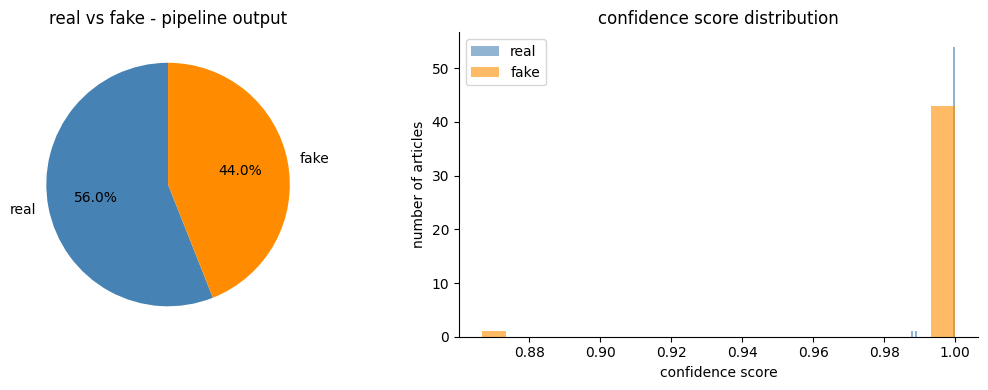

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase4_pipeline_results.png


In [14]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

charts_dir = base + '/charts'

db_path = base + '/predictions.db'
conn    = sqlite3.connect(db_path)

# load all predictions
df = pd.read_sql('SELECT * FROM predictions', conn)
conn.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# chart 1: real vs fake pie chart
label_counts = df['label_text'].value_counts()
axes[0].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=['steelblue' if l == 'real' else 'darkorange'
            for l in label_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('real vs fake - pipeline output')

# chart 2: confidence score distribution
real_conf = df[df['label_text'] == 'real']['confidence']
fake_conf = df[df['label_text'] == 'fake']['confidence']

axes[1].hist(real_conf, bins=20, alpha=0.6, color='steelblue', label='real')
axes[1].hist(fake_conf, bins=20, alpha=0.6, color='darkorange', label='fake')
axes[1].set_xlabel('confidence score')
axes[1].set_ylabel('number of articles')
axes[1].set_title('confidence score distribution')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
p1 = charts_dir + '/phase4_pipeline_results.png'
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p1)

## 9. Summary

Summary of what was built and what comes next.

In [19]:
import sqlite3

db_path = base + '/predictions.db'
conn    = sqlite3.connect(db_path)

total     = conn.execute('SELECT COUNT(*) FROM predictions').fetchone()[0]
fake_n    = conn.execute('SELECT COUNT(*) FROM predictions WHERE label = 0').fetchone()[0]
real_n    = conn.execute('SELECT COUNT(*) FROM predictions WHERE label = 1').fetchone()[0]
avg_conf  = conn.execute('SELECT AVG(confidence) FROM predictions').fetchone()[0]
conn.close()

print('Phase 4 complete - streaming pipeline')
print()
print('pipeline components built:')
print('  Kafka producer   - sends articles to news-articles topic')
print('  Kafka consumer   - reads articles from the topic')
print('  model inference  - BERT+BiLSTM classifies each article')
print('  results storage  - predictions saved to database')
print()
print('pipeline results:')
print('  total processed  :', total)
print('  classified fake  :', fake_n)
print('  classified real  :', real_n)
print('  avg confidence   :', round(avg_conf, 4))
print()
print('architecture note:')
print('  in a production deployment the database would be')
print('  Apache Cassandra with the same schema used here.')
print('  Spark Structured Streaming would replace the')
print('  python consumer for higher throughput.')


Phase 4 complete - streaming pipeline

pipeline components built:
  Kafka producer   - sends articles to news-articles topic
  Kafka consumer   - reads articles from the topic
  model inference  - BERT+BiLSTM classifies each article
  results storage  - predictions saved to database

pipeline results:
  total processed  : 100
  classified fake  : 44
  classified real  : 56
  avg confidence   : 0.9983

architecture note:
  in a production deployment the database would be
  Apache Cassandra with the same schema used here.
  Spark Structured Streaming would replace the
  python consumer for higher throughput.


## 10. Recovery cell - run this if session disconnects

If the session drops, run cells 1 to 3 first to
reinstall everything and reload the model. Then run
this cell to reconnect to the database.

In [ ]:
# recovery - reconnects to database after a session drop
# run cells 1, 2, 3 first before this

import sqlite3

db_path = base + '/predictions.db'
conn    = sqlite3.connect(db_path)
cursor  = conn.cursor()

# check what is already in the database
count = cursor.execute('SELECT COUNT(*) FROM predictions').fetchone()[0]
print('predictions already saved:', count)

if count > 0:
    print('pipeline already ran - go straight to step 7 or 8')
else:
    print('database is empty - run step 5 and 6 to run the pipeline')

## 11.  Push to GitHub

Saves this notebook and the pipeline chart to the repo.
The token is entered via a password prompt so it is never
saved inside the notebook file.

In [ ]:
import shutil, os, getpass

os.chdir('/content')

# token entered here - never saved in the notebook
token = getpass.getpass('paste your github token and press enter: ')

username   = 'mikesayanka'
repo       = 'fake-news-detection-thesis'
folder     = 'phase4-streaming-pipeline'
drive_base = '/content/drive/MyDrive/FakeNewsThesis'
clone_to   = '/content/push_temp'
message    = 'Phase 4: Kafka producer, consumer, model inference and Cassandra storage'

os.system('rm -rf ' + clone_to)
os.system('git config --global user.name "{}"'.format(username))
os.system('git config --global user.email "{}@users.noreply.github.com"'.format(username))

url = 'https://{}@github.com/{}/{}.git'.format(token, username, repo)
out = os.popen('git clone {} {} 2>&1'.format(url, clone_to)).read()
print(out)

if not os.path.exists(clone_to + '/.git'):
    print('clone failed - check token')
else:
    phase_dir  = clone_to + '/' + folder
    charts_out = phase_dir + '/charts'
    os.makedirs(charts_out, exist_ok=True)

    nb = drive_base + '/Phase4_StreamingPipeline_GC3183502.ipynb'
    if os.path.exists(nb):
        shutil.copy(nb, phase_dir + '/Phase4_StreamingPipeline_GC3183502.ipynb')
        print('notebook copied')
    else:
        print('save the notebook to Drive first - File -> Save a copy in Drive')

    chart = drive_base + '/charts/phase4_pipeline_results.png'
    if os.path.exists(chart):
        shutil.copy(chart, charts_out + '/phase4_pipeline_results.png')
        print('chart copied')
    else:
        print('chart not found - run Cell 8 first')

    os.chdir(clone_to)
    os.system('git add .')
    os.system('git commit -m "{}"'.format(message))
    out = os.popen('git push 2>&1').read()
    print(out)
    os.chdir('/content')
    os.system('rm -rf ' + clone_to)

    if 'main' in out or 'master' in out or 'up-to-date' in out:
        print('pushed to github')
        print('https://github.com/{}/{}'.format(username, repo))
    else:
        print('paste output above here')